In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
df = pd.read_csv('ml models/games.csv')
df.head(10)
df.columns

Index(['id', 'rated', 'created_at', 'last_move_at', 'turns', 'victory_status',
       'winner', 'increment_code', 'white_id', 'white_rating', 'black_id',
       'black_rating', 'moves', 'opening_eco', 'opening_name', 'opening_ply'],
      dtype='str')

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20058 entries, 0 to 20057
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              20058 non-null  str    
 1   rated           20058 non-null  bool   
 2   created_at      20058 non-null  float64
 3   last_move_at    20058 non-null  float64
 4   turns           20058 non-null  int64  
 5   victory_status  20058 non-null  str    
 6   winner          20058 non-null  str    
 7   increment_code  20058 non-null  str    
 8   white_id        20058 non-null  str    
 9   white_rating    20058 non-null  int64  
 10  black_id        20058 non-null  str    
 11  black_rating    20058 non-null  int64  
 12  moves           20058 non-null  str    
 13  opening_eco     20058 non-null  str    
 14  opening_name    20058 non-null  str    
 15  opening_ply     20058 non-null  int64  
dtypes: bool(1), float64(2), int64(4), str(9)
memory usage: 2.3 MB


In [4]:
df.isnull().sum()

id                0
rated             0
created_at        0
last_move_at      0
turns             0
victory_status    0
winner            0
increment_code    0
white_id          0
white_rating      0
black_id          0
black_rating      0
moves             0
opening_eco       0
opening_name      0
opening_ply       0
dtype: int64

In [5]:
df.drop([
    'id',
    'created_at',
    'last_move_at',
    'white_id',
    'black_id',
    'moves',
    'victory_status'
], axis=1,inplace = True)


In [6]:
df['opening_name'].value_counts()

opening_name
Van't Kruijs Opening                                                    368
Sicilian Defense                                                        358
Sicilian Defense: Bowdler Attack                                        296
French Defense: Knight Variation                                        271
Scotch Game                                                             271
                                                                       ... 
Sicilian Defense: Scheveningen Variation |  English Attack                1
Pirc Defense: Austrian Attack |  Kurajica Variation                       1
Queen's Indian Defense: Classical Variation |  Traditional Variation      1
Queen's Gambit Declined: Slav |  Dutch Variation                          1
Sicilian Defense: Najdorf Variation |  Polugaevsky Variation              1
Name: count, Length: 1477, dtype: int64

In [7]:
df.describe()

,turns,white_rating,black_rating,opening_ply
count,20058.000000,20058.000000,20058.000000,20058.000000
mean,60.465999,1596.631868,1588.831987,4.816981
std,33.570585,291.253376,291.036126,2.797152
min,1.000000,784.000000,789.000000,1.000000
25%,37.000000,1398.000000,1391.000000,3.000000
50%,55.000000,1567.000000,1562.000000,4.000000
75%,79.000000,1793.000000,1784.000000,6.000000
max,349.000000,2700.000000,2723.000000,28.000000


In [8]:
df = pd.get_dummies(df, columns=['opening_eco'], drop_first=True,dtype=int)


In [9]:
df

,rated,turns,winner,increment_code,white_rating,black_rating,opening_name,opening_ply,opening_eco_A01,opening_eco_A02,...,opening_eco_E81,opening_eco_E87,opening_eco_E88,opening_eco_E90,opening_eco_E91,opening_eco_E92,opening_eco_E94,opening_eco_E95,opening_eco_E97,opening_eco_E98
0,False,13,white,15+2,1500,1191,Slav Defense: Exchange Variation,5,0,0,...,0,0,0,0,0,0,0,0,0,0
1,True,16,black,5+10,1322,1261,Nimzowitsch Defense: Kennedy Variation,4,0,0,...,0,0,0,0,0,0,0,0,0,0
2,True,61,white,5+10,1496,1500,King's Pawn Game: Leonardis Variation,3,0,0,...,0,0,0,0,0,0,0,0,0,0
3,True,61,white,20+0,1439,1454,Queen's Pawn Game: Zukertort Variation,3,0,0,...,0,0,0,0,0,0,0,0,0,0
4,True,95,white,30+3,1523,1469,Philidor Defense,5,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20053,True,24,white,10+10,1691,1220,Dutch Defense,2,0,0,...,0,0,0,0,0,0,0,0,0,0
20054,True,82,black,10+0,1233,1196,Queen's Pawn,2,0,0,...,0,0,0,0,0,0,0,0,0,0
20055,True,35,white,10+0,1219,1286,Queen's Pawn Game: Mason Attack,3,0,0,...,0,0,0,0,0,0,0,0,0,0
20056,True,109,white,10+0,1360,1227,Pirc Defense,4,0,0,...,0,0,0,0,0,0,0,0,0,0


In [10]:
df.columns

Index(['rated', 'turns', 'winner', 'increment_code', 'white_rating',
       'black_rating', 'opening_name', 'opening_ply', 'opening_eco_A01',
       'opening_eco_A02',
       ...
       'opening_eco_E81', 'opening_eco_E87', 'opening_eco_E88',
       'opening_eco_E90', 'opening_eco_E91', 'opening_eco_E92',
       'opening_eco_E94', 'opening_eco_E95', 'opening_eco_E97',
       'opening_eco_E98'],
      dtype='str', length=372)

In [11]:
df['opening_name'].nunique()

1477

In [12]:
df['opening_name'].value_counts().head(20)

opening_name
Van't Kruijs Opening                             368
Sicilian Defense                                 358
Sicilian Defense: Bowdler Attack                 296
French Defense: Knight Variation                 271
Scotch Game                                      271
Scandinavian Defense: Mieses-Kotroc Variation    259
Queen's Pawn Game: Mason Attack                  232
Queen's Pawn Game: Chigorin Variation            229
Scandinavian Defense                             223
Horwitz Defense                                  209
Caro-Kann Defense                                199
Philidor Defense #3                              198
Philidor Defense #2                              193
Indian Game                                      181
Italian Game: Anti-Fried Liver Defense           180
Four Knights Game: Italian Variation             176
Modern Defense                                   174
Owen Defense                                     168
King's Pawn Game: Wayward Queen A

In [13]:
opening_counts = df['opening_name'].value_counts()

df['opening_frequency'] = df['opening_name'].map(opening_counts)

In [14]:
df

,rated,turns,winner,increment_code,white_rating,black_rating,opening_name,opening_ply,opening_eco_A01,opening_eco_A02,...,opening_eco_E87,opening_eco_E88,opening_eco_E90,opening_eco_E91,opening_eco_E92,opening_eco_E94,opening_eco_E95,opening_eco_E97,opening_eco_E98,opening_frequency
0,False,13,white,15+2,1500,1191,Slav Defense: Exchange Variation,5,0,0,...,0,0,0,0,0,0,0,0,0,19
1,True,16,black,5+10,1322,1261,Nimzowitsch Defense: Kennedy Variation,4,0,0,...,0,0,0,0,0,0,0,0,0,5
2,True,61,white,5+10,1496,1500,King's Pawn Game: Leonardis Variation,3,0,0,...,0,0,0,0,0,0,0,0,0,154
3,True,61,white,20+0,1439,1454,Queen's Pawn Game: Zukertort Variation,3,0,0,...,0,0,0,0,0,0,0,0,0,114
4,True,95,white,30+3,1523,1469,Philidor Defense,5,0,0,...,0,0,0,0,0,0,0,0,0,135
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20053,True,24,white,10+10,1691,1220,Dutch Defense,2,0,0,...,0,0,0,0,0,0,0,0,0,48
20054,True,82,black,10+0,1233,1196,Queen's Pawn,2,0,0,...,0,0,0,0,0,0,0,0,0,129
20055,True,35,white,10+0,1219,1286,Queen's Pawn Game: Mason Attack,3,0,0,...,0,0,0,0,0,0,0,0,0,232
20056,True,109,white,10+0,1360,1227,Pirc Defense,4,0,0,...,0,0,0,0,0,0,0,0,0,19


In [15]:
df['increment_code'].value_counts().head(20)

increment_code
10+0     7721
15+0     1311
15+15     850
5+5       738
5+8       697
8+0       588
10+5      579
15+10     461
20+0      448
30+0      375
10+10     355
15+5      314
7+2       265
10+2      187
30+30     169
5+10      155
25+0      152
10+3      149
10+8      123
20+10     103
Name: count, dtype: int64

In [16]:
df['increment_code'].dtype

<StringDtype(storage='python', na_value=nan)>

In [17]:
df

,rated,turns,winner,increment_code,white_rating,black_rating,opening_name,opening_ply,opening_eco_A01,opening_eco_A02,...,opening_eco_E87,opening_eco_E88,opening_eco_E90,opening_eco_E91,opening_eco_E92,opening_eco_E94,opening_eco_E95,opening_eco_E97,opening_eco_E98,opening_frequency
0,False,13,white,15+2,1500,1191,Slav Defense: Exchange Variation,5,0,0,...,0,0,0,0,0,0,0,0,0,19
1,True,16,black,5+10,1322,1261,Nimzowitsch Defense: Kennedy Variation,4,0,0,...,0,0,0,0,0,0,0,0,0,5
2,True,61,white,5+10,1496,1500,King's Pawn Game: Leonardis Variation,3,0,0,...,0,0,0,0,0,0,0,0,0,154
3,True,61,white,20+0,1439,1454,Queen's Pawn Game: Zukertort Variation,3,0,0,...,0,0,0,0,0,0,0,0,0,114
4,True,95,white,30+3,1523,1469,Philidor Defense,5,0,0,...,0,0,0,0,0,0,0,0,0,135
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20053,True,24,white,10+10,1691,1220,Dutch Defense,2,0,0,...,0,0,0,0,0,0,0,0,0,48
20054,True,82,black,10+0,1233,1196,Queen's Pawn,2,0,0,...,0,0,0,0,0,0,0,0,0,129
20055,True,35,white,10+0,1219,1286,Queen's Pawn Game: Mason Attack,3,0,0,...,0,0,0,0,0,0,0,0,0,232
20056,True,109,white,10+0,1360,1227,Pirc Defense,4,0,0,...,0,0,0,0,0,0,0,0,0,19


In [18]:
df[['initial_time', 'increment']] = df['increment_code'].str.split('+', expand=True)

df['initial_time'] = df['initial_time'].astype(float)
df['increment'] = df['increment'].astype(float)

In [19]:
df[['increment_code', 'initial_time', 'increment']].head()

,increment_code,initial_time,increment
0,15+2,15.0,2.0
1,5+10,5.0,10.0
2,5+10,5.0,10.0
3,20+0,20.0,0.0
4,30+3,30.0,3.0


In [20]:
df = df.drop('increment_code', axis=1)

In [21]:
df

,rated,turns,winner,white_rating,black_rating,opening_name,opening_ply,opening_eco_A01,opening_eco_A02,opening_eco_A03,...,opening_eco_E90,opening_eco_E91,opening_eco_E92,opening_eco_E94,opening_eco_E95,opening_eco_E97,opening_eco_E98,opening_frequency,initial_time,increment
0,False,13,white,1500,1191,Slav Defense: Exchange Variation,5,0,0,0,...,0,0,0,0,0,0,0,19,15.0,2.0
1,True,16,black,1322,1261,Nimzowitsch Defense: Kennedy Variation,4,0,0,0,...,0,0,0,0,0,0,0,5,5.0,10.0
2,True,61,white,1496,1500,King's Pawn Game: Leonardis Variation,3,0,0,0,...,0,0,0,0,0,0,0,154,5.0,10.0
3,True,61,white,1439,1454,Queen's Pawn Game: Zukertort Variation,3,0,0,0,...,0,0,0,0,0,0,0,114,20.0,0.0
4,True,95,white,1523,1469,Philidor Defense,5,0,0,0,...,0,0,0,0,0,0,0,135,30.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20053,True,24,white,1691,1220,Dutch Defense,2,0,0,0,...,0,0,0,0,0,0,0,48,10.0,10.0
20054,True,82,black,1233,1196,Queen's Pawn,2,0,0,0,...,0,0,0,0,0,0,0,129,10.0,0.0
20055,True,35,white,1219,1286,Queen's Pawn Game: Mason Attack,3,0,0,0,...,0,0,0,0,0,0,0,232,10.0,0.0
20056,True,109,white,1360,1227,Pirc Defense,4,0,0,0,...,0,0,0,0,0,0,0,19,10.0,0.0


In [22]:
df['rated'].value_counts()

rated
True     16155
False     3903
Name: count, dtype: int64

In [23]:
df['rated'] = df['rated'].astype(int)

In [24]:

df['winner'].value_counts()

winner
white    10001
black     9107
draw       950
Name: count, dtype: int64

In [25]:
df['winner'] = df['winner'].map({
    'white': 0,
    'black': 1,
    'draw': 2
})

In [26]:
df['winner'].value_counts()

winner
0    10001
1     9107
2      950
Name: count, dtype: int64

In [27]:
df['opening_ply'].describe()

count    20058.000000
mean         4.816981
std          2.797152
min          1.000000
25%          3.000000
50%          4.000000
75%          6.000000
max         28.000000
Name: opening_ply, dtype: float64

In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20058 entries, 0 to 20057
Columns: 374 entries, rated to increment
dtypes: float64(2), int64(371), str(1)
memory usage: 57.2 MB


In [29]:
df.select_dtypes(include='str').columns

Index(['opening_name'], dtype='str')

In [30]:
opening_counts = df['opening_name'].value_counts()

df['opening_frequency'] = df['opening_name'].map(opening_counts)

In [31]:
df[['opening_name', 'opening_frequency']].head()

,opening_name,opening_frequency
0,Slav Defense: Exchange Variation,19
1,Nimzowitsch Defense: Kennedy Variation,5
2,King's Pawn Game: Leonardis Variation,154
3,Queen's Pawn Game: Zukertort Variation,114
4,Philidor Defense,135


In [32]:
df.drop('opening_name', axis=1, inplace=True)

In [33]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20058 entries, 0 to 20057
Columns: 373 entries, rated to increment
dtypes: float64(2), int64(371)
memory usage: 57.1 MB


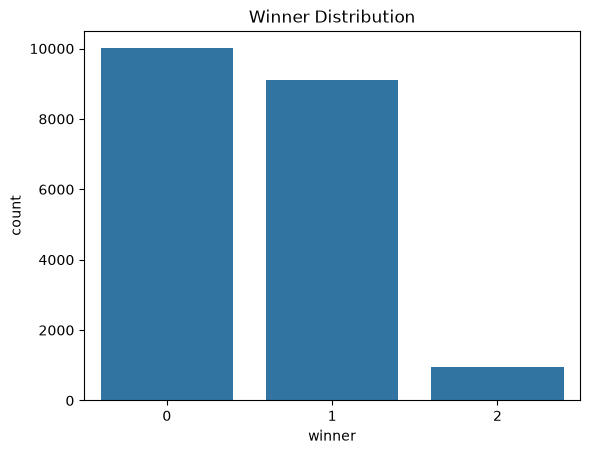

In [34]:
sns.countplot(x='winner', data=df)
plt.title('Winner Distribution')
plt.show()

In [35]:
X = df.drop('winner',axis = 1)
y = df['winner']

In [36]:
from sklearn.model_selection import train_test_split
X_train, X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42 ,stratify=y)

In [37]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [38]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

In [39]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_test_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_test_pred, average='weighted'))

Accuracy: 0.6435692921236291
Precision: 0.6520271605585026
Recall: 0.6435692921236291
F1 Score: 0.6340348818809519


In [40]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_test_pred)

print(cm)

[[1427  572    1]
 [ 688 1131    3]
 [  96   70   24]]


In [41]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.65      0.71      0.68      2000
           1       0.64      0.62      0.63      1822
           2       0.86      0.13      0.22       190

    accuracy                           0.64      4012
   macro avg       0.71      0.49      0.51      4012
weighted avg       0.65      0.64      0.63      4012



In [42]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_test_pred)
print(cm)

[[1427  572    1]
 [ 688 1131    3]
 [  96   70   24]]


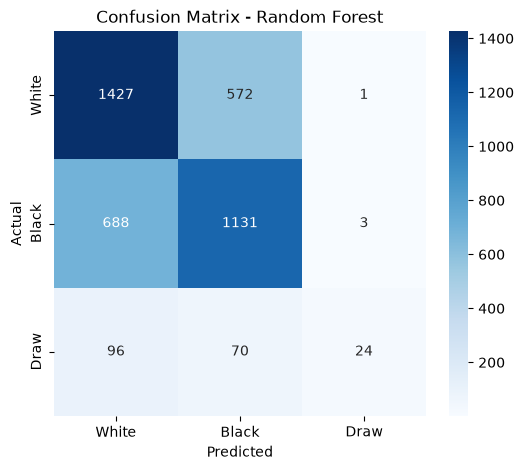

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['White', 'Black', 'Draw'],
    yticklabels=['White', 'Black', 'Draw']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest')
plt.show()

In [44]:
accuracy_score(y_train, y_train_pred)
accuracy_score(y_test, y_test_pred)

0.6435692921236291

In [45]:
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

Training Accuracy: 1.0
Testing Accuracy: 0.6435692921236291


In [46]:
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

feature_importance.head(20)

,feature,importance
3,black_rating,0.179719
2,white_rating,0.176561
1,turns,0.151485
369,opening_frequency,0.077867
370,initial_time,0.065795
371,increment,0.056960
4,opening_ply,0.048112
0,rated,0.016898
156,opening_eco_C00,0.005287
76,opening_eco_B01,0.004949


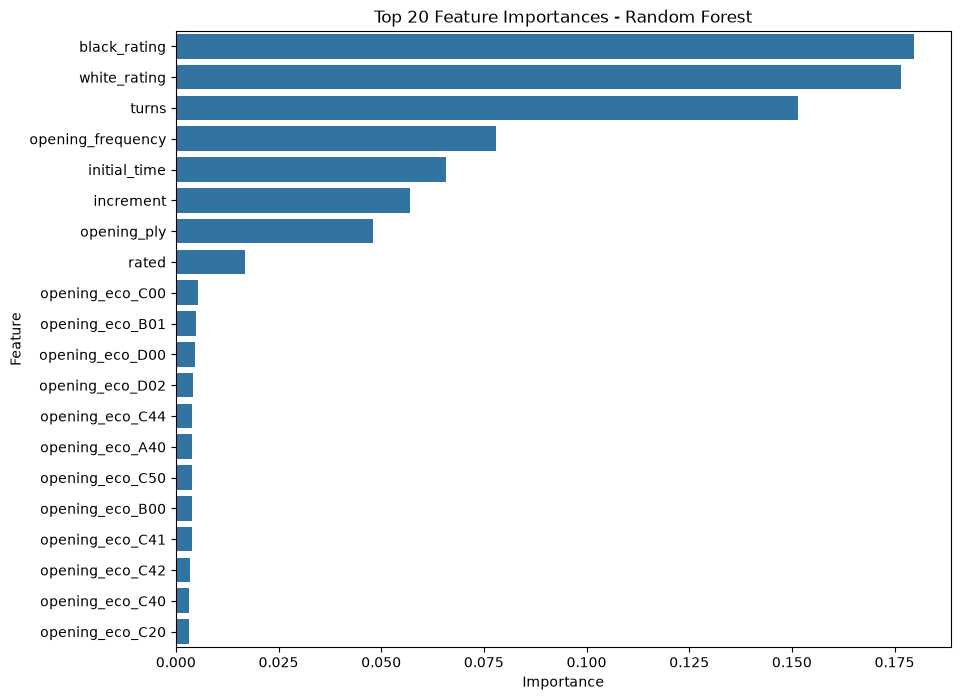

In [47]:
plt.figure(figsize=(10, 8))

sns.barplot(
    data=feature_importance.head(20),
    x='importance',
    y='feature'
)

plt.title('Top 20 Feature Importances - Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()